# Day 11: The Bloch sphere

**Fri, Oct 16 · Intro · about 30 minutes**

Every single-qubit state is a point on a sphere. It's the picture the course will use for single-qubit gates, noise and error correction.

**By the end of this notebook you can:**
- Write any single-qubit state as cos(θ/2)|0⟩ + e^(iφ) sin(θ/2)|1⟩
- Place |0⟩, |1⟩, |+⟩, |−⟩ and |i⟩ on the sphere
- See gates as rotations of the sphere

> How to use this notebook: read each explanation, run the cell under it, then change the numbers and run it again.
> The exercises at the end have a "your turn" cell and a hidden worked solution. Try first, then check.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (5, 5), "axes.grid": True, "grid.alpha": 0.3})

def tex(label):
    """Typeset a ket label like '|+>' as a proper |+⟩ in plots."""
    if label.startswith("|") and label.endswith(">"):
        return r"$|" + label[1:-1] + r"\rangle$"
    return label

ket0 = np.array([1, 0], dtype=complex)
ket1 = np.array([0, 1], dtype=complex)
plus = (ket0 + ket1) / np.sqrt(2)
minus = (ket0 - ket1) / np.sqrt(2)

## 1. From two complex numbers to two angles
Any normalised state can be written (ignoring an unobservable global phase) as

**|ψ⟩ = cos(θ/2)|0⟩ + e^(iφ) sin(θ/2)|1⟩**

- **θ** (0 to π) is the angle down from the north pole, where |0⟩ sits.
- **φ** (0 to 2π) is the angle around the equator, measured from the +x axis.

The point on the sphere is (x, y, z) = (sin θ cos φ, sin θ sin φ, cos θ).

In [2]:
def bloch_angles(psi):
    psi = psi / np.linalg.norm(psi)
    psi = psi * np.exp(-1j * np.angle(psi[0])) if abs(psi[0]) > 1e-12 else psi  # remove global phase
    theta = 2 * np.arccos(np.clip(abs(psi[0]), 0, 1))
    phi = np.angle(psi[1]) % (2 * np.pi) if abs(psi[1]) > 1e-12 else 0.0
    return theta, phi

def bloch_xyz(theta, phi):
    return np.array([np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi), np.cos(theta)])

plus_i = (ket0 + 1j * ket1) / np.sqrt(2)
states = {"|0>": ket0, "|1>": ket1, "|+>": plus, "|->": minus, "|i>": plus_i}
for name, s in states.items():
    th, ph = bloch_angles(s)
    print(f"{name:4s} theta = {th/np.pi:.2f}pi, phi = {ph/np.pi:.2f}pi, point = {np.round(bloch_xyz(th, ph), 3)}")

|0>  theta = 0.00pi, phi = 0.00pi, point = [0. 0. 1.]
|1>  theta = 1.00pi, phi = 0.00pi, point = [ 0.  0. -1.]
|+>  theta = 0.50pi, phi = 0.00pi, point = [1. 0. 0.]
|->  theta = 0.50pi, phi = 1.00pi, point = [-1.  0.  0.]
|i>  theta = 0.50pi, phi = 0.50pi, point = [0. 1. 0.]


## 2. Draw the sphere

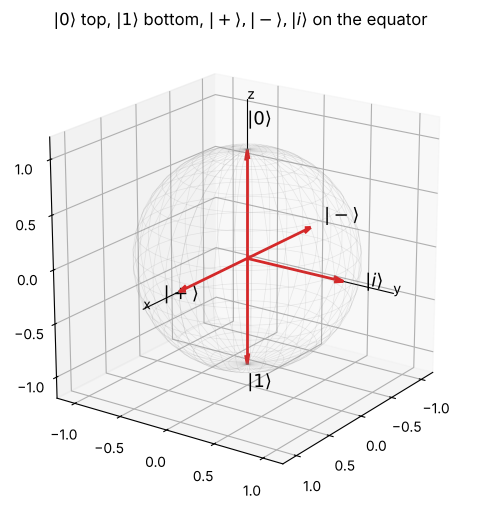

In [3]:
def draw_bloch(points, title="Bloch sphere"):
    fig = plt.figure(figsize=(6, 6)); ax = fig.add_subplot(projection="3d")
    u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
    ax.plot_wireframe(np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v), color="gray", alpha=0.15, lw=0.5)
    for d, lab in [((1.5, 0, 0), "x"), ((0, 1.5, 0), "y"), ((0, 0, 1.45), "z")]:
        ax.plot([0, d[0]], [0, d[1]], [0, d[2]], color="k", lw=0.8); ax.text(*d, lab)
    for name, (th, ph) in points.items():
        p = bloch_xyz(th, ph)
        ax.quiver(0, 0, 0, *p, color="C3", arrow_length_ratio=0.1, lw=2)
        ax.text(*(p * 1.22), tex(name), fontsize=13)
    ax.set_box_aspect((1, 1, 1)); ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2); ax.set_zlim(-1.2, 1.2)
    ax.set_title(title); ax.view_init(elev=20, azim=35); plt.show()

draw_bloch({n: bloch_angles(s) for n, s in states.items()}, r"$|0\rangle$ top, $|1\rangle$ bottom, $|+\rangle, |-\rangle, |i\rangle$ on the equator")

## 3. Gates rotate the sphere
**Rz(α)** = diag(e^(−iα/2), e^(iα/2)) spins the sphere about the z axis. It changes φ but never θ, so measurement probabilities in the 0/1 basis don't change.
Below, Rz is applied to |+⟩ in eight steps of π/4, walking it around the equator.

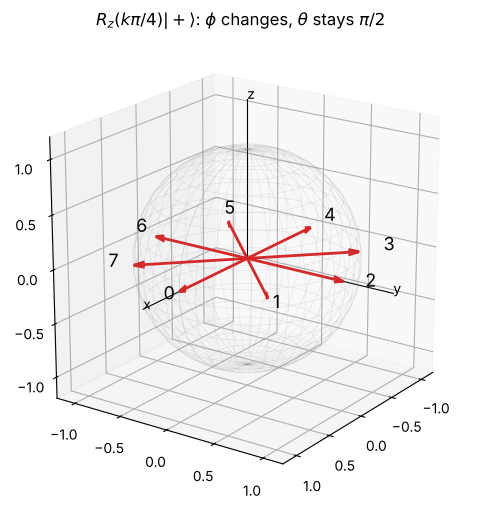

thetas: [np.float64(0.5), np.float64(0.5), np.float64(0.5), np.float64(0.5), np.float64(0.5), np.float64(0.5), np.float64(0.5), np.float64(0.5)] (all 0.5 pi)


In [4]:
def Rz(a): return np.array([[np.exp(-1j * a / 2), 0], [0, np.exp(1j * a / 2)]])
walk = {f"{k}": bloch_angles(Rz(k * np.pi / 4) @ plus) for k in range(8)}
draw_bloch(walk, r"$R_z(k\pi/4)|+\rangle$: $\phi$ changes, $\theta$ stays $\pi/2$")
print("thetas:", [round(t / np.pi, 3) for t, _ in walk.values()], "(all 0.5 pi)")

## Exercises
**E1.** Give θ and φ for |0⟩, |1⟩, |+⟩ and |−⟩.

**E2.** Where on the sphere is (|0⟩ + i|1⟩)/√2?

**E3.** Show Rz(α) doesn't change P(0) for any state.

In [5]:
# Your turn

<details>
<summary><b>Show worked solution</b></summary>

**E1.** |0⟩: θ = 0 (north pole). |1⟩: θ = π (south pole). |+⟩: θ = π/2, φ = 0 (+x). |−⟩: θ = π/2, φ = π (−x).

**E2.** cos(θ/2) = 1/√2 gives θ = π/2, and e^(iφ) = i gives φ = π/2. That's the **+y** point on the equator.

**E3.** Rz multiplies the |0⟩ amplitude by e^(−iα/2), which has modulus 1, so |amplitude|² and therefore P(0) are unchanged.

</details>

In [6]:
expected = {"|0>": (0, None), "|1>": (np.pi, None), "|+>": (np.pi/2, 0), "|->": (np.pi/2, np.pi), "|i>": (np.pi/2, np.pi/2)}
for n, (th, ph) in expected.items():
    t, p = bloch_angles(states[n])
    assert np.isclose(t, th) and (ph is None or np.isclose(p, ph)), n
psi = np.array([0.6, 0.8j])
assert np.isclose(abs((Rz(1.234) @ psi)[0])**2, abs(psi[0])**2)
print("All Day 11 checks passed. You're ready for Oct 17.")

All Day 11 checks passed. You're ready for Oct 17.


---
### Recap checklist
Tick these off in your head before moving on. If any feel shaky, re-run the relevant section with your own numbers.

*Part of the IIT Delhi CEP Applied Quantum Computing & AI prep plan: [prep-plan.md](../plan/prep-plan.md)*